### This is supposed to indicate the multi-hopping network of the node distribution 

/tmp/ipykernel_7770/2420098436.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


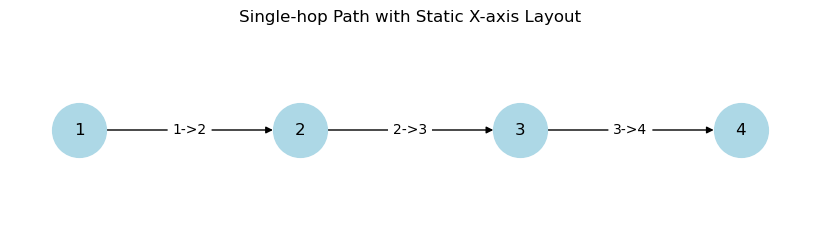

'./singlehop.png'

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Define nodes and their measurements
nodes = {
    1: {'measurement': 10},
    2: {'measurement': 20},
    3: {'measurement': 30},
    4: {'measurement': 0}  # sink node
}

# Add nodes with attributes
G.add_nodes_from([(n, attr) for n, attr in nodes.items()])

# Define edges for multi-hopping (e.g., 1 → 2 → 3 → 4)
edges = [(1, 2), (2, 3), (3, 4)]
G.add_edges_from(edges)

# Propagate measurements hop-by-hop
def propagate_measurements(G, sink):
    cumulative = {n: [] for n in G.nodes}
    for node in nx.topological_sort(G):
        current_measurement = G.nodes[node]['measurement']
        if current_measurement:
            cumulative[node].append(current_measurement)
        for succ in G.successors(node):
            cumulative[succ].extend(cumulative[node])
    return cumulative[sink]

# Aggregate at sink node
sink_node = 4
aggregated = propagate_measurements(G, sink_node)

# Static positions along x-axis
pos = {
    1: (0, 0),
    2: (1, 0),
    3: (2, 0),
    4: (3, 0)
}

# Draw the graph
plt.figure(figsize=(8, 2))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1500, arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): f"{u}->{v}" for u, v in edges})
plt.title("Single-hop Path with Static X-axis Layout")
plt.axis('off')

# Save the graph first
png_path = "./singlehop.png"
plt.tight_layout()
plt.savefig(png_path, format='png')

# Show the graph
plt.show()

# Return the path to the saved image
png_path


/tmp/ipykernel_7770/2576581771.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


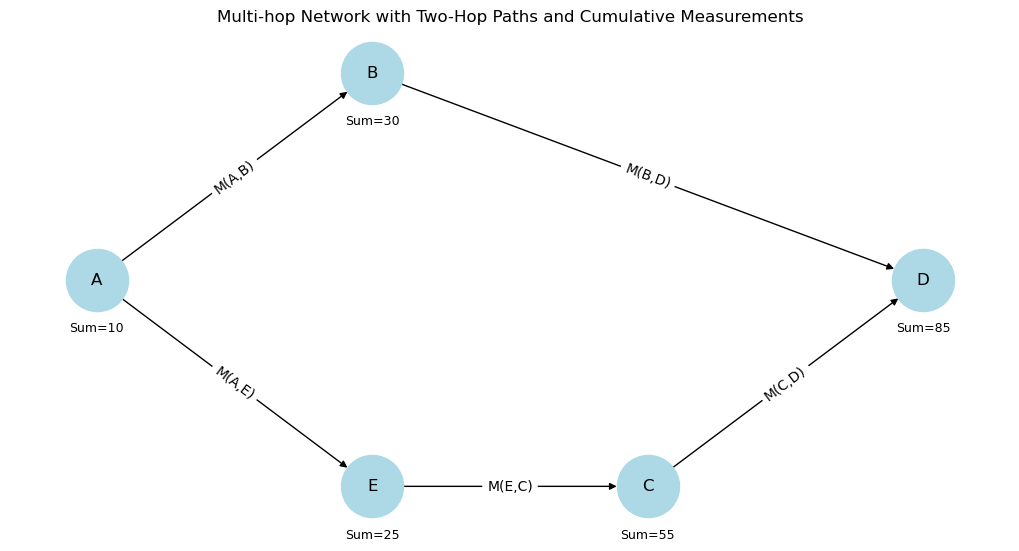


Aggregated data at D: [('A', 10), ('B', 20), ('A', 10), ('E', 15), ('C', 30)]
Total Sum at D: 85


In [28]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the directed graph
G = nx.DiGraph()

# Define nodes and their measurements
nodes = {
    'A': {'measurement': 10},
    'B': {'measurement': 20},
    'E': {'measurement': 15},
    'C': {'measurement': 30},
    'D': {'measurement': 0}  # sink node
}

# Add nodes with attributes
G.add_nodes_from([(n, attr) for n, attr in nodes.items()])

# Define multi-hop paths:
# A → B → D
# A → E → C → D
edges = [
    ('A', 'B'),
    ('B', 'D'),
    ('A', 'E'),
    ('E', 'C'),
    ('C', 'D')
]
G.add_edges_from(edges)

# Define static positions for nodes
positions = {
    'A': (0, 1),
    'B': (1, 2),
    'E': (1, 0),
    'C': (2, 0),
    'D': (3, 1)
}

# Function to propagate measurements
def propagate_measurements(G):
    cumulative = {n: [] for n in G.nodes}
    for node in nx.topological_sort(G):
        current_measurement = G.nodes[node]['measurement']
        if current_measurement:
            cumulative[node].append((node, current_measurement))
        for succ in G.successors(node):
            cumulative[succ].extend(cumulative[node])
    return cumulative

# Get cumulative measurement data
cumulative_info = propagate_measurements(G)

# Draw the graph
plt.figure(figsize=(10, 5))
nx.draw(G, pos=positions, with_labels=True, node_color='lightblue', node_size=2000, arrows=True)

# Label each edge as M(Source, Destination)
edge_labels = {(u, v): f"M({u},{v})" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos=positions, edge_labels=edge_labels, font_size=10)

# Display cumulative sum at each node
for node, (x, y) in positions.items():
    cum_data = [str(val) for _, val in cumulative_info[node]]
    cum_sum = sum(val for _, val in cumulative_info[node])
    cum_label = f"Sum={cum_sum}" if cum_data else "Sum=0"
    plt.text(x, y - 0.25, cum_label, ha='center', fontsize=9)

plt.title("Multi-hop Network with Two-Hop Paths and Cumulative Measurements")
plt.axis('off')
plt.tight_layout()
plt.show()

# Print aggregation at sink
sink = 'D'
agg = cumulative_info[sink]
print(f"\nAggregated data at {sink}: {agg}")
print(f"Total Sum at {sink}: {sum(val for _, val in agg)}")


/tmp/ipykernel_7770/752813318.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


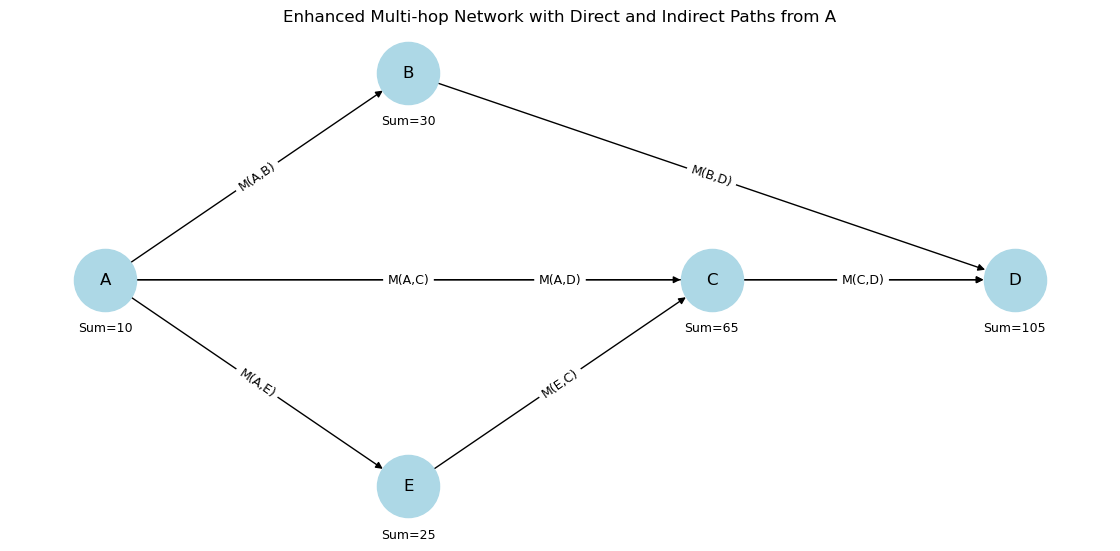

In [29]:
import networkx as nx
import matplotlib.pyplot as plt

# Define directed graph
G = nx.DiGraph()

# Define nodes with measurements
nodes = {
    'A': {'measurement': 10},
    'B': {'measurement': 20},
    'E': {'measurement': 15},
    'C': {'measurement': 30},
    'D': {'measurement': 0}
}
G.add_nodes_from([(n, attr) for n, attr in nodes.items()])

# Define all multi-hop and direct edges
edges = [
    ('A', 'B'),
    ('B', 'D'),
    ('A', 'E'),
    ('E', 'C'),
    ('C', 'D'),
    ('A', 'C'),
    ('A', 'D')
]
G.add_edges_from(edges)

# Static layout
positions = {
    'A': (0, 1),
    'B': (1, 2),
    'E': (1, 0),
    'C': (2, 1),
    'D': (3, 1)
}

# Propagate measurements
def propagate_measurements(G):
    cumulative = {n: [] for n in G.nodes}
    for node in nx.topological_sort(G):
        current_measurement = G.nodes[node]['measurement']
        if current_measurement:
            cumulative[node].append((node, current_measurement))
        for succ in G.successors(node):
            cumulative[succ].extend(cumulative[node])
    return cumulative

# Get propagation results
cumulative_info = propagate_measurements(G)

# Draw graph
plt.figure(figsize=(11, 5))
nx.draw(G, pos=positions, with_labels=True, node_color='lightblue', node_size=2000, arrows=True)

# Edge labels in M(Source, Destination)
edge_labels = {(u, v): f"M({u},{v})" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos=positions, edge_labels=edge_labels, font_size=9)

# Display cumulative values under each node
for node, (x, y) in positions.items():
    cum_data = [str(val) for _, val in cumulative_info[node]]
    cum_sum = sum(val for _, val in cumulative_info[node])
    label = f"Sum={cum_sum}" if cum_data else "Sum=0"
    plt.text(x, y - 0.25, label, ha='center', fontsize=9)

# Save before showing or closing
png_path = "./multihopping.png"
plt.title("Enhanced Multi-hop Network with Direct and Indirect Paths from A")
plt.axis('off')
plt.tight_layout()
plt.savefig(png_path, format='png')
plt.show()
